In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

from InSitu14CO import Propagator
import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

from Firn_Model import Accumulation_Site

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def smooth_diff(f):
    return np.concatenate(( [(f[1]-f[0])], (f[2:]-f[:-2])/2, [(f[-1]-f[-2])] ), axis=0)

In [4]:
def efilter(x, lambd): # x cannot grow or decay faster than an exponential rate
    
    for i in range(1,len(x)):
        if x[i]/x[i-1] > np.exp(1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(1/lambd[i-1])
        elif x[i]/x[i-1] < np.exp(-1/lambd[i-1]):
            x[i] = x[i-1]*np.exp(-1/lambd[i-1])
    return x

In [5]:
def cum_mat_prod(A,N):
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

## Load Matlab Run

In [6]:
runMat = scipy.io.loadmat('matlab/Firn Ice Model/Firn Model - CIC Forward Model v5.0/Runs/Run2026-07-21_08h59m.mat')
runMat

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Tue Jul 21 09:00:16 2026',
 '__version__': '1.0',
 '__globals__': [],
 'Acc': array([[0.032]]),
 'None': MatlabOpaque([(b'An2', b'MCOS', b'matlab.graphics.shape.TextBox', array([[3707764736],
                      [         2],
                      [         1],
                      [         1],
                      [         1],
                      [         2]], dtype=uint32))                                    ],
              dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]),
 'ApplyUncert': array([[0]], dtype=uint8),
 'Apply_14CO_adj': array([[0]], dtype=uint8),
 'C14CH4_color': array([[0, 1, 0]], dtype=uint8),
 'C14CO2_color': array([[0.2 , 0.73, 1.  ]]),
 'C14CO_color': array([[0.8, 0.8, 0. ]]),
 'C14CO_const': array([[12]], dtype=uint8),
 'C14CO_const_u': array([[2]], dtype=uint8),
 'C14CO_hist': array(['constant'], dtype='<U8'),
 'C14CO_hist_dX_lin': array([[-0.6]]),
 'C14CO_hist_dX_pct': arr

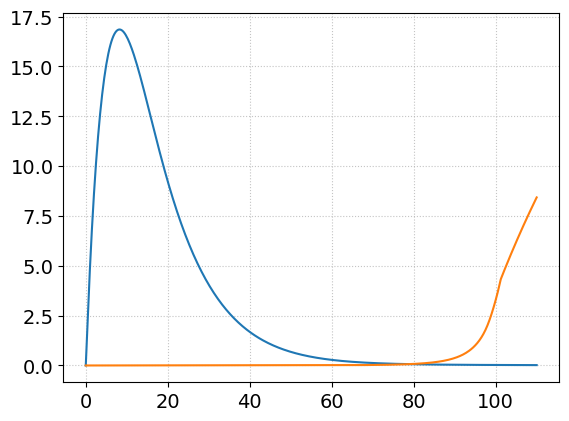

In [7]:
plt.plot(runMat['z'], runMat['C14_grains'][:,-1,1])
plt.plot(runMat['z'], runMat['C14_closed'][:,-1,1])

## Set Parameters

In [8]:
#COS_partition = np.array(
#    [#CO2         CO          CH4
#    [0.686307104, 0.31125305, 0.002439846], # neutron
#    [0.686307104, 0.31125305, 0.002439846], # neg muon
#    [0.686307104, 0.31125305, 0.002439846], # fast muon
#])
COS_partition = runMat['COS_partition']

#L = np.array([1, 7e-4])
L = np.array([1,runMat['leakage'][0,0]['closed'][0,1]])
Res = runMat['Res_partition'][0]

#f_factors = np.array([1., 0.06, 0.08])
#P0_tuning = f_factors / np.array([1, COS_partition[0,1], COS_partition[0,1]]) * COS_partition[0,1]
P0_tuning = runMat['P0_tuning'][0] * COS_partition[0,1]
f_factors = P0_tuning * np.array([1/COS_partition[0,1], 1, 1])
f_factors

array([1.03 , 0.065, 0.07 ])

## Load Propagator Model

In [9]:
Prop_DC = Propagator()

## Load Firn Model

In [88]:
#Dome_C = Accumulation_Site(t_resol=10)
Dome_C = Accumulation_Site(#z_end=runMat['z_end'][0,0],
                           #t_end=runMat['t_end'][0,0],
                           t_resol=10,
                           #C14CO_const=int(runMat['C14CO_const'][0,0]),
                           #Acc=runMat['Acc'][0,0],
                          )

# caculate cosmogenic 14C in reservoirs w/ Leakage rates L
C14_grains, C14_leak_open, C14_leak_closed, C14_cumuleak_closed = Dome_C.Calc_14C_ice(L=L)

# calculate 14CO concentrations in open porosity, + concentration trapped into closed porosity
C14_open_gas, C14_closed_gas, C14_open_atm, C14_closed_atm, c_gases = Dome_C.Calc_profiles(C14_leak_open, analytic=True)

/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:219: RuntimeWarning: invalid value encountered in divide
  bubble_pres = np.sum((dscl * C * self.s)[None,:] * self.dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(self.s*(self.s_closed-self.s_closed[0]))
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:356: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:358: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(lambd+Lrate)*(COS_age+COS_dt)) * np.cumsum((COS_P).reshape((-1,3,1)) * np.exp((lambd+Lrate)*COS_age) * COS_dt, axis=0)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:594: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)


0.008444547653198242
interpolating...


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 167.43it/s]

integrating...
  Calculated open and closed profiles for gas 1 out of 1
0.09603548049926758


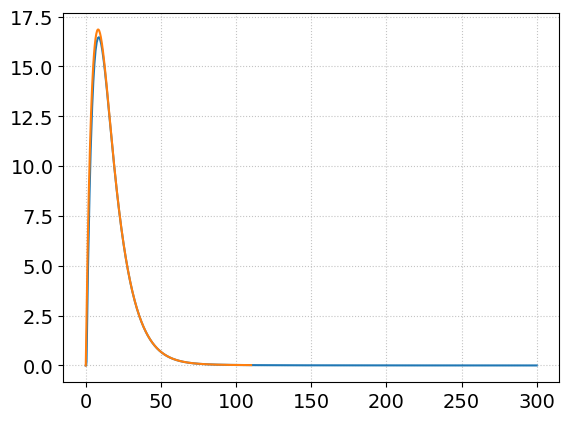

In [89]:
plt.plot(Dome_C.z, P0_tuning @ C14_grains @ Res)
plt.plot(runMat['z'], runMat['C14_grains'][:,-1,1])

/tmp/ipykernel_1471/374335906.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(Dome_C.z[:len(runMat['z'])], (P0_tuning @ C14_grains @ Res)[:len(runMat['z'])]/runMat['C14_grains'][:,-1,1]-1)


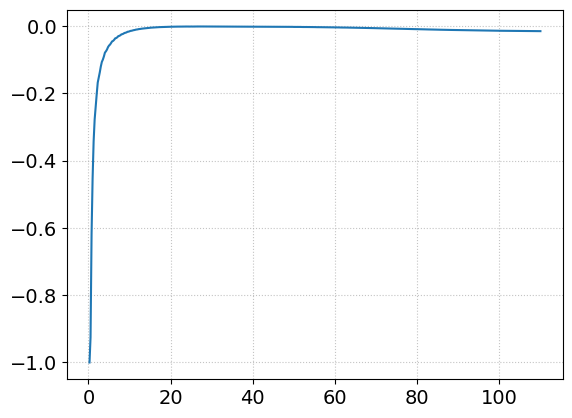

In [90]:
plt.plot(Dome_C.z[:len(runMat['z'])], (P0_tuning @ C14_grains @ Res)[:len(runMat['z'])]/runMat['C14_grains'][:,-1,1]-1)

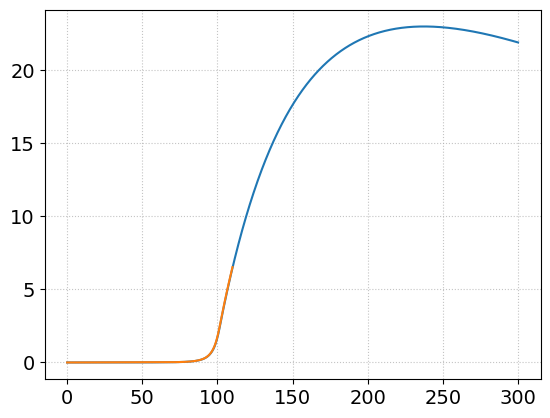

In [91]:
plt.plot(Dome_C.z, P0_tuning @ (C14_cumuleak_closed) @ Res)
plt.plot(runMat['z'], runMat['C14_closed'][:,-2,1])

/tmp/ipykernel_1471/1139977583.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(Dome_C.z[:len(runMat['z'])], (P0_tuning @ (C14_cumuleak_closed) @ Res)[:len(runMat['z'])] / runMat['C14_closed'][:,-2,1]-1)


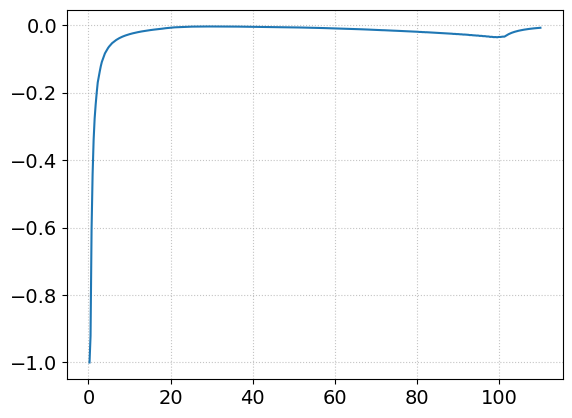

In [92]:
plt.plot(Dome_C.z[:len(runMat['z'])], (P0_tuning @ (C14_cumuleak_closed) @ Res)[:len(runMat['z'])] / runMat['C14_closed'][:,-2,1]-1)

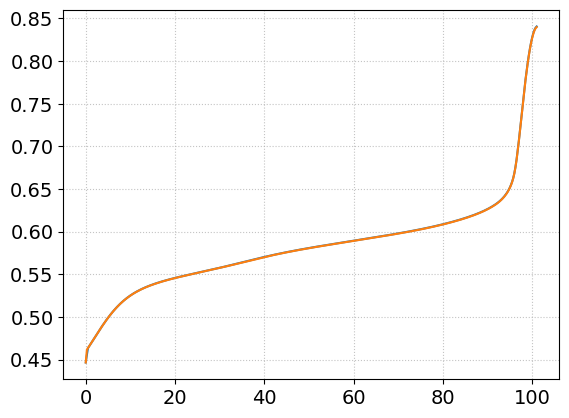

In [93]:
plt.plot(Dome_C.z[:Dome_C.teller_co], P0_tuning @ (c_gases[:Dome_C.teller_co,1:].reshape(-1,3,2)) @ Res + c_gases[:Dome_C.teller_co,0])
plt.plot(runMat['z'], runMat['c_open'][:,-1])

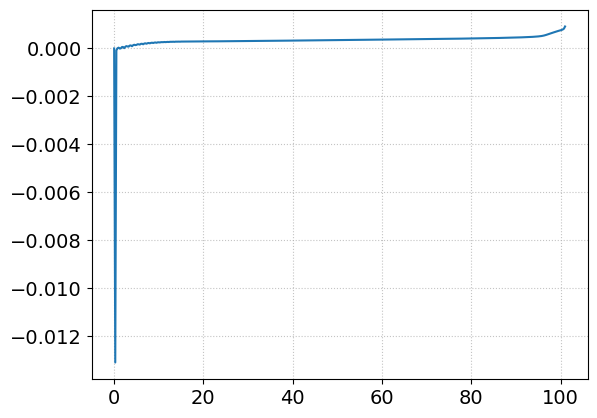

In [94]:
plt.plot(Dome_C.z[:Dome_C.teller_co], (P0_tuning @ (c_gases[:Dome_C.teller_co,1:].reshape(-1,3,2)) @ Res + c_gases[:Dome_C.teller_co,0]) / runMat['c_open'][:Dome_C.teller_co,-1]-1)

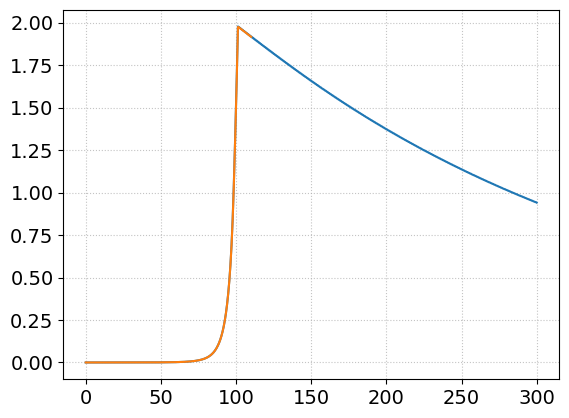

In [95]:
plt.plot(Dome_C.z, P0_tuning @ (C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'])
plt.plot(runMat['z'], runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])

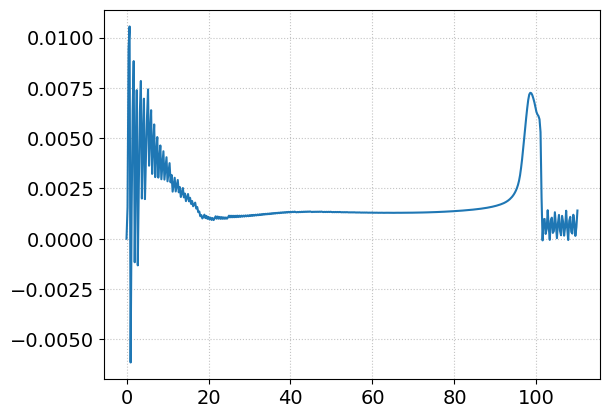

In [96]:
plt.plot(Dome_C.z[:len(runMat['z'])], (P0_tuning @ (C14_closed_gas['C14_CO']) @ Res + C14_closed_atm['C14_CO'])[:len(runMat['z'])] / (runMat['C14_closed'][:,-1,1]-runMat['C14_closed'][:,-2,1])-1)

## Load Samples

In [97]:
pd_DomeC = pd.read_excel('DomeC 14CO data analysis current.xlsx', '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])
pd_DomeC

,"Mean depth, m","14CO, molec / g ice after all corrections","Error, 1 sigma","Mean gas age, yr before 1950","Mean gas age, Years before measurement date"
Sample,,,,,
14CO_UR_DC_FIRN_SAMPLE_1,34.000,46.438967,1.143309,NaN,NaN
14CO_UR_DC_FIRN_SAMPLE_2,54.500,28.289650,0.749249,NaN,NaN
14CO_UR_DC_FIRN_EXTRACTION_3,75.000,18.807095,0.543124,NaN,NaN
14CO_UR_DC_ICE_SAMPLE_1,110.000,18.669397,0.885088,434.483581,510.483581
14CO_UR_DC_ICE_SAMPLE_3,150.000,26.848805,0.679599,1901.485970,1977.485970
14CO_UR_DC_ICE_SAMPLE_4,170.000,28.480674,0.573240,2717.573599,2793.573599
14CO_UR_DC_ICE_SAMPLE_5,190.500,29.289987,0.601586,3323.027758,3399.027758
14CO_UR_DC_ICE_SAMPLE_6,211.000,29.666008,0.722400,4118.909061,4194.909061
14CO_UR_DC_ICE_SAMPLE_7,230.925,28.951245,0.655983,4761.798084,4837.798084


In [98]:
z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
# separate samples into categories
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

## Setup Grids

In [153]:
#lambd = Prop_DC.lambd
lambd = Dome_C.decay_gas['C14_CO']
lambd

0.00012096286440062901

(1201,)


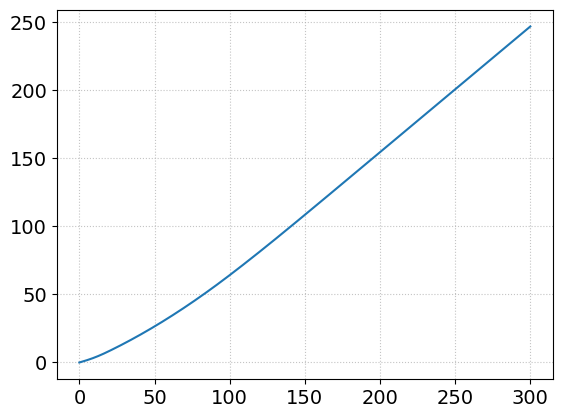

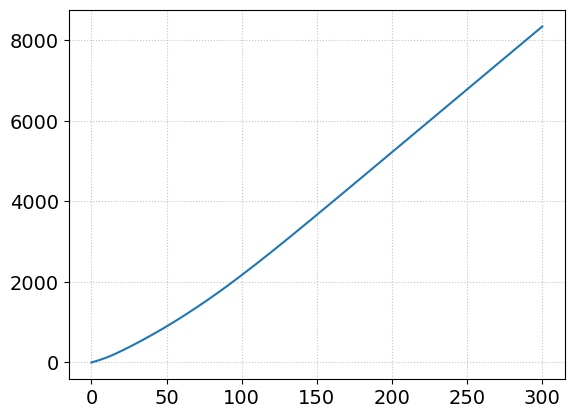

In [154]:
# age & depth grids [grid]
New = False
if New:
    z_grid = Prop_DC.z_grid
    h_grid = Prop_DC.h_grid
    age_grid = Prop_DC.age_grid
else:
    z_grid = Dome_C.z
    h_grid = Dome_C.IceAge * Dome_C.Acc * Dome_C.rho_ice
    age_grid = Dome_C.IceAge
print(z_grid.shape)

plt.plot(z_grid, h_grid)
plt.show()

plt.plot(z_grid, age_grid)
plt.show()

In [155]:
# Production times [bins]
#dt1 = 10
dt1 = Dome_C.t_resol
if New:
    t1_bins = np.arange(0, age_grid[-1]+dt1, dt1)
    t1_bins = t1_bins-t1_bins[-1]
    t1 = (t1_bins[:-1]+t1_bins[1:])/2
else:
    t1 = Dome_C.t_int
t1.shape

(1001,)

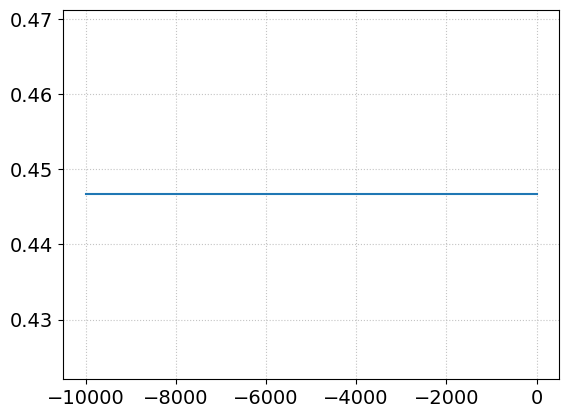

In [156]:
# Atmospheric 14CO history
gas_history = Dome_C.gas_history['C14_CO'][0]*np.ones(len(t1))
plt.plot(t1, gas_history)

In [157]:
# Diffusion time resolution
dt_D = Dome_C.dt
dt_D

0.01

In [158]:
# Production depths [grid]
if New:
    p = Prop_DC.h_bins
else:
    Site = Dome_C
    p_dt = dt1
    p_t = np.arange(-Site.t_end, 1e-10, p_dt)

    #ice-eqiv depth
    dp = Site.Acc * p_dt
    p = np.arange(dp/2, Site.dz * np.sum(Site.rho)/Site.rho_ice + 2 * Site.dz, dp) * Site.rho_ice # depth bin centers
    dp *= Site.rho_ice

    # interpolate COS_z to real depth, integrating “dummy” density to get mass depth ranges
    p_z = np.interp(p, scipy.integrate.cumulative_trapezoid([*Site.rho, Site.rho_ice], x=[*Site.z, Site.z[-1]+30], initial=0), [*Site.z, Site.z[-1]+30])

    # Run the calculation
    p_age = np.arange(len(p_z))*p_dt+p_dt/2 # age of ice at ice-eq depth COS_z
p.shape

(836,)

(1e-05, 200.0)

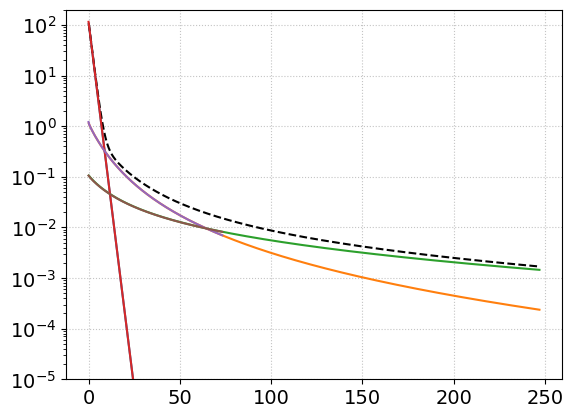

In [159]:
# Production Rates [grid]
P_m = np.array(Dome_C.COS_Production(p/Dome_C.rho_ice))
P = P0_tuning @ P_m
plt.plot(p, (P0_tuning[:,None]*P_m).T)
plt.plot(p, P, ls='--', c='k')
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pn'][:,-1])
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pmu'][:,-1])
plt.plot(runMat['COS_z']*runMat['rho_ice'], COS_partition[0,1]*runMat['COS_Pmuf'][:,-1])
plt.yscale('log')
plt.ylim(1e-5,2e2)

In [160]:
# Accumulation Depths [bins]
if New:
    age_bins = t1_bins-t1_bins[0]
    age = (age_bins[:-1]+age_bins[1:])/2
    dage = np.diff(age_bins)
    dage_bins = smooth_diff(age_bins)

    h_bins = np.interp(age_bins, age_grid, h_grid)
    h = (h_bins[:-1]+h_bins[1:])/2
    dh = np.diff(h_bins)
    dh_bins = smooth_diff(h_bins)

    z_bins = np.interp(age_bins, age_grid, z_grid)
    z = (z_bins[:-1]+z_bins[1:])/2
    dz = np.diff(z_bins)
    dz_bins = smooth_diff(z_bins)
else:
    z = z_grid
    dz = smooth_diff(z)
    
    h = h_grid
    dh = smooth_diff(h)
    
    age = age_grid
    dage = smooth_diff(age)

age.shape

(1201,)

In [161]:
sample_widths = np.array([100]*len(z_exp)) #widths of ice core sample depth ranges [m]

z_samp_bins = z_exp[None,:] + sample_widths[None,:]*np.array([-0.5,0.5])[:,None]
#z_samp_bins = Prop_DC.z_samp_bins
z_samp = (z_samp_bins[0]+z_samp_bins[1])/2
dz_samp = z_samp_bins[1]-z_samp_bins[0]

h_samp_bins = np.interp(z_samp_bins, z_grid, h_grid)
h_samp = (h_samp_bins[0]+h_samp_bins[1])/2
dh_samp = h_samp_bins[1]-h_samp_bins[0]

#axis0 - Lower/Upper Bound (0-lower, 1-upper)
#axis1 - Sample bin (s)
z_samp_bins.shape

(2, 16)

## Density & Porosity Profile

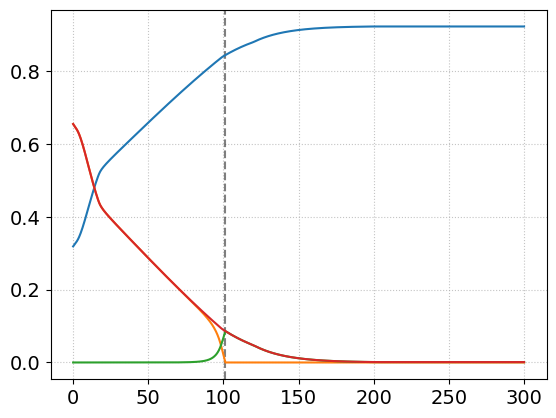

In [162]:
# Densities and Porosities
rho = dh/dz
if not New:
    rho = Dome_C.rho
rho_ice = max(0.9165 - (Dome_C.T-273.15)*1.4438e-4 - (Dome_C.T-273.15)**2 * 1.5175e-7, max(rho)+1e-9) # Schwander et al.
rho_co = 0.833 # density at close off depth? idk

s = 1 - rho/rho_ice # porosity of ice by depth
s_closed = (0.37 * s * (s/(1-rho_co/rho_ice))**(-7.6)).clip(max=s) # closed porosity
s_open = s - s_closed # open porosity

teller_co = np.argmax(s_closed) # depth index of maximum closed porosity (close off depth??)

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z,rho)
plt.plot(z,s_open)
plt.plot(z,s_closed)
plt.plot(z,s)

## Tortuosity & Diff_m

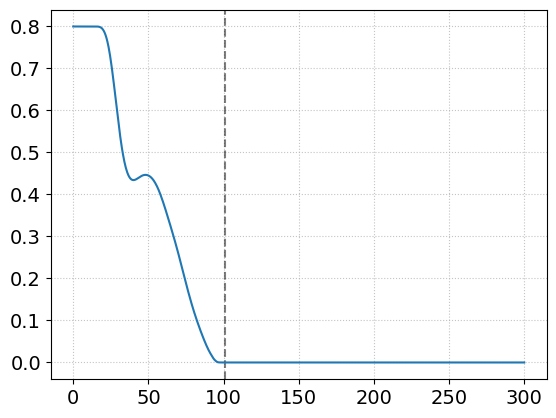

In [163]:
tort_file = 'Firn_Model_Tortuosity_DomeC.csv'
Profiles = np.array(pd.read_csv(tort_file))
InvTort = np.interp(z, Profiles[:,0], Profiles[:,1]) # inverse Tortuosity D(z) = D^0 * Inv tort
Diff_m = np.interp(z, Profiles[:,0], Profiles[:,2]) # dispersive mixing in lock-in zone

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, InvTort)

## Bubble Pressure & Velocity

In [164]:
Site = Dome_C

g = Site.g
R = Site.R
T = Site.T
pressure = Site.pressure
M_air = Site.M_air
H_eddy = Site.H_eddy
D_0eddy = Site.D_0eddy

/tmp/ipykernel_1471/188295240.py:18: RuntimeWarning: invalid value encountered in divide
  bubble_pres = np.sum((dscl * C_air * s)[None,:] * dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(s*(s_closed-s_closed[0]))


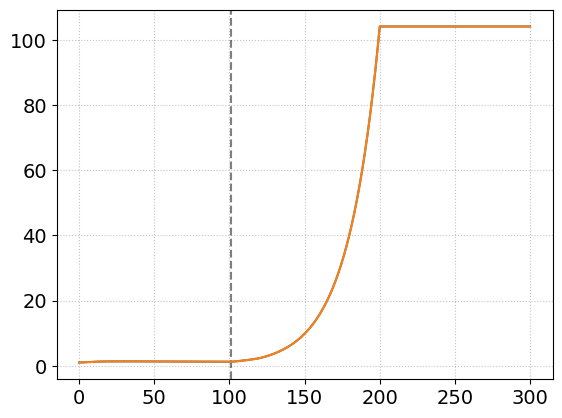

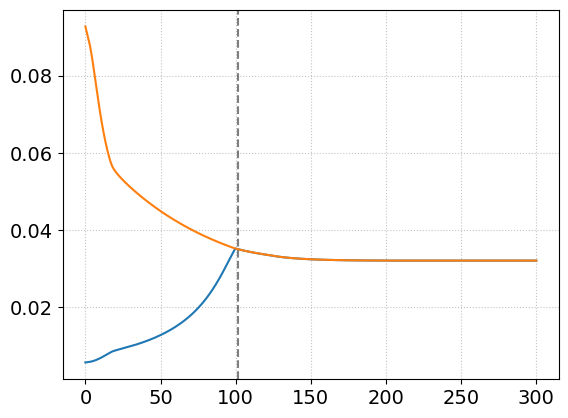

In [165]:
bubble_pres = np.zeros(z.shape)

#dscl = smooth_diff(s_closed)/dz # ds_closed / dz
dscl = np.diff(s_closed, prepend=s_closed[0])/dz # ds_closed / dz

C_air = np.exp(M_air * g * z / (R * T) )
if New:
    Acc = np.mean(dh/dage)
else:
    Acc = Dome_C.Acc * Dome_C.rho_ice
v_ice = Acc / rho # downwards ice velocity
#v_ice = dz/dage

#strain = smooth_diff( np.log(v_ice))/dz # d log(v_ice) / dz
#strainsum = scipy.integrate.cumulative_trapezoid(strain, dx=self.dz, initial=0)
strainsum = np.log(v_ice)
i = np.arange(len(z))
bubble_pres = np.sum((dscl * C_air * s)[None,:] * dz / (1+strainsum[:,None]-strainsum[None,:]) * (i[None,:]<=i[:,None]), axis=-1)/(s*(s_closed-s_closed[0]))
#bubble_pres = dz*(np.cumsum(dscl*C_air*s)*(1+np.log(v_ice)) - np.cumsum(dscl*C_air*s*np.log(v_ice)))/(s_closed-s_closed[0]+1e-18)/s
#bubble_pres = dz*(np.cumsum(dscl*C_air*s)*(1+np.log(v_ice)) - np.cumsum(dscl*C_air*s*np.log(v_ice)))/(s_closed-s_closed[0])/s
# Divide by zero error at the first index, so we set that to 1
bubble_pres[0] = 1 # what are the units here??

# After teller_co:
bubble_pres[teller_co+1:] = bubble_pres[teller_co] * s[teller_co] / s[teller_co+1:] * v_ice[teller_co] / v_ice[teller_co+1:]
# bubble pres is directly inverse to s and v_ice below close-off depth

flux = v_ice[teller_co+1] * bubble_pres[teller_co+1] * s_closed[teller_co+1]

velocity = np.minimum(v_ice, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air) )
velocity = velocity#/(60*60*24*365.25) # convert to m/s

#never used:
#air_content = 1000 * bubble_pres[teller_co+1] * s_closed[teller_co+1] * pressure / 101325 * 273.15 / T / rho[teller_co+1]

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, bubble_pres)
plt.plot(z, Dome_C.bubble_pres)
#plt.yscale('log')
plt.show()

plt.axvline(z[teller_co], ls='--', c='k', alpha=0.5)
plt.plot(z, velocity)#*(60*60*24*365.25))
#plt.plot(z, (flux + 1e-10 - v_ice * bubble_pres * s_closed) / ((s_open + 1e-10) * C_air))
plt.plot(z, v_ice)
#plt.plot(z, Dome_C.v_ice)
plt.show()

## Crank Nicholson Parameters

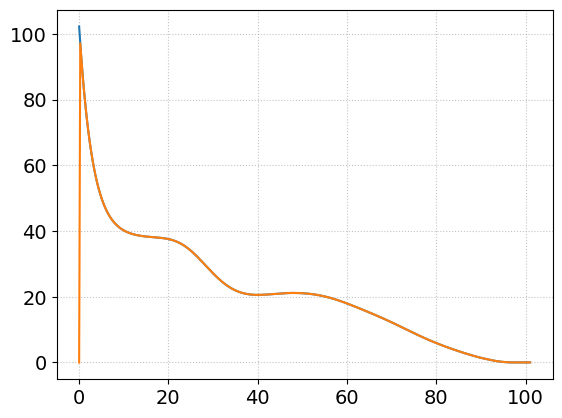

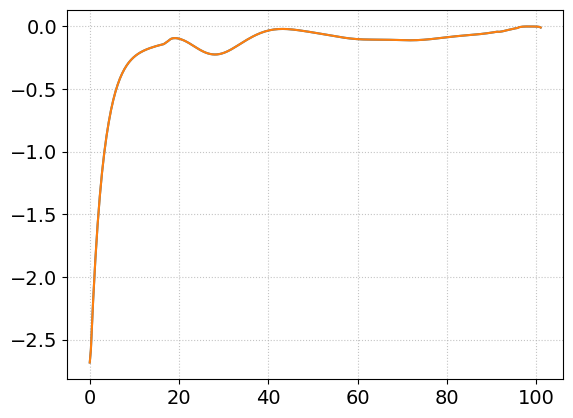

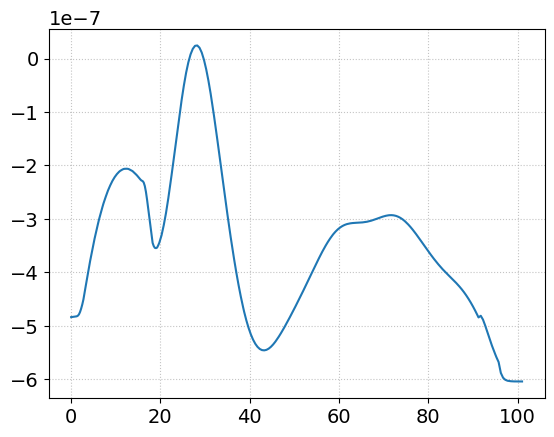

In [166]:
gas = 'C14_CO'
Site = Dome_C

L_trace = lambd/(60*60*24*365.25)
M_air = Site.M_air
g = Site.g
R = Site.R
T = Site.T

Q = teller_co

# Molecular diffusivity part:
Diff   =  InvTort * Site.D_gas[gas]

M_trace = Site.M_gas[gas]

# Eddy diffusivity part:
Diff_e = efilter(D_0eddy*np.exp(-z/H_eddy),0.5/np.diff(z))*(z<55) # Convection following Kawamura et al
Diff_e = np.maximum(Diff_e, Diff_m)    # Add dispersion in the LIZ

# Take the derivatives
porecl = smooth_diff(Diff*C_air*(s_open+1e-9))/dz/((s_open+1e-9)*C_air)#.clip(min=1e-20)
porecl_e = smooth_diff(Diff_e*C_air*(s_open+1e-9))/dz/((s_open+1e-9)*C_air)#.clip(min=1e-20)

porecl[teller_co]   = porecl[teller_co+1]
porecl_e[teller_co] = porecl_e[teller_co+1]

# c_t = alpha*c_zz + beta*c_z + gamma*c

alpha =  (dt_D*60*60*24*365.25/2/dz**2) * (Diff+Diff_e)
alpha2 =  (dt_D*60*60*24*365.25/2) * (Diff+Diff_e)
alpha2[1:-1] = alpha2[1:-1] / ((z[2:]-z[1:-1])*(z[1:-1]-z[:-2])*(z[2:]-z[:-2])/2)
alpha2[[0,-1]] = 0

beta  =  (dt_D*60*60*24*365.25/4/dz) * (Diff*(M_air-M_trace)*g/(R*T) + (Diff_e)*(M_air)*g/(R*T) + porecl + porecl_e -velocity/(60*60*24*365.25))
beta2  =  (dt_D*60*60*24*365.25/4/smooth_diff(z)) * (Diff*(M_air-M_trace)*g/(R*T) + (Diff_e)*(M_air)*g/(R*T) + porecl + porecl_e -velocity/(60*60*24*365.25))

gamma =  (dt_D*60*60*24*365.25/2) * (porecl*(M_air-M_trace)*g/(R*T) +  -L_trace)

plt.plot(z[:Q], alpha[:Q])
plt.plot(z[:Q], alpha2[:Q]*(z[1:Q+1]-z[:Q]))
plt.show()

plt.plot(z[:Q], beta[:Q])
plt.plot(z[:Q], beta2[:Q])
plt.show()

plt.plot(z[:Q], gamma[:Q])
plt.show()

## Crank-Nicholson Matrix

In [167]:
Q = teller_co+20

#i = 0
i=-1
#"""
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha[1:Q+i] - beta[1:Q+i], [0])),
        np.concatenate(([1], 1-2*alpha[1:Q+i]+gamma[1:Q+i], [0])),
        np.concatenate(([0], alpha[1:Q+i] + beta[1:Q+i] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha[1:Q+i] - beta[1:Q+i]), [-1])),
        np.concatenate(([1], 1+2*alpha[1:Q+i]-gamma[1:Q+i], [1])),
        np.concatenate(([0], -1*(alpha[1:Q+i] + beta[1:Q+i]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

"""
A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha2[1:Q]*(z[2:Q+1+i]-z[1:Q+i]) - beta2[1:Q+i], [0])),
        np.concatenate(([1], 1-alpha2[1:Q+i]*(z[2:Q+1+i]-z[:Q-1+i])+gamma[1:Q+i], [0])),
        np.concatenate(([0], alpha2[1:Q+i]*(z[1:Q+i]-z[:Q-1+i]) + beta2[1:Q+i] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha2[1:Q+i]*(z[2:Q+1+i]-z[1:Q+i]) - beta2[1:Q+i]), [-1])),
        np.concatenate(([1], 1+alpha2[1:Q+i]*(z[2:Q+1+i]-z[:Q-1+i])-gamma[1:Q+i], [1])),
        np.concatenate(([0], -1*(alpha2[1:Q+i]*(z[1:Q+i]-z[:Q-1+i]) + beta2[1:Q+i]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
).toarray()
#"""

A_inv = np.linalg.inv(A_back)
D = A_inv @ A_for
#A_inv = scipy.sparse.linalg.inv(A_back)
#D = (A_inv @ A_for).toarray()
D[0] = 0
D1 = np.copy(D)
D = np.linalg.matrix_power(D,int(dt1/dt_D))
D.shape

(425, 425)

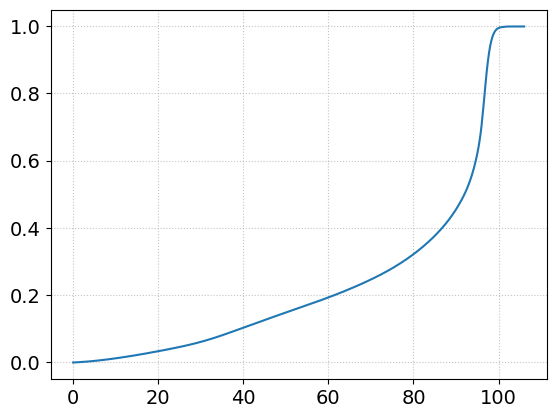

In [168]:
plt.plot(z[:Q], np.sum(D, axis=1))

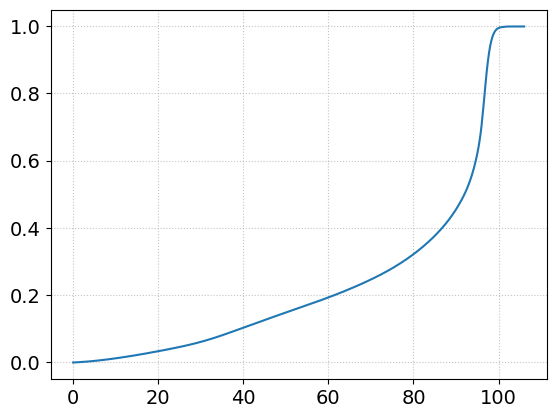

In [169]:
plt.plot(z[:Q], np.sum(np.linalg.matrix_power(Dome_C.D,int(dt1/dt_D)),axis=1))

In [170]:
np.linalg.matrix_power(Dome_C.D,int(dt1/dt_D))-D

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.92500096e-16, -7.19584982e-16,  1.16074685e-15, ...,
        -7.72008541e-21, -4.86312559e-21, -8.49685250e-23],
       [ 3.37512136e-16,  4.13081028e-17, -6.81095805e-16, ...,
        -1.58622524e-20, -9.99215056e-21, -1.74582852e-22],
       ...,
       [ 1.73543003e-15,  8.77714686e-18,  1.79918475e-17, ...,
        -1.06581410e-14, -7.20257187e-15, -1.26201133e-16],
       [ 1.16021389e-15,  5.86984597e-18,  1.20323329e-17, ...,
        -7.61890551e-15, -5.09314813e-15, -8.93382590e-17],
       [ 1.16021389e-15,  5.86984597e-18,  1.20323329e-17, ...,
        -7.61890551e-15, -5.09314813e-15, -8.93382590e-17]])

In [171]:
N_D = int(1000/dt1) # maximum number of diffusion timesteps worth considering
D_t = np.moveaxis(cum_mat_prod(D,N_D),0,-1)
#D_t = np.moveaxis(cum_mat_prod(np.linalg.matrix_power(Dome_C.D,int(dt1/dt_D)),N_D),0,-1)
D_t.shape

100%|█████████████████████████████████████████████████████████████████████████████████| 99/99 [00:00<00:00, 1450.99it/s]


(425, 425, 100)

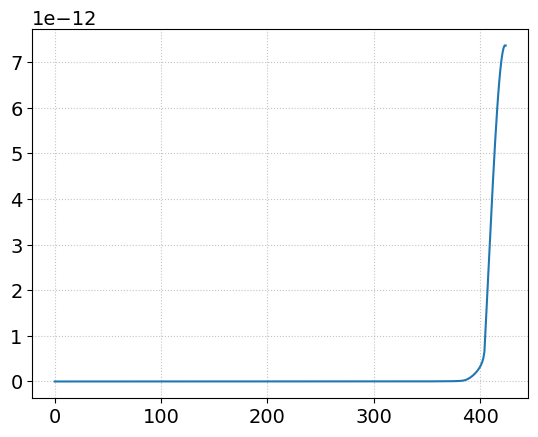

In [172]:
# after ~200 years only ~1e-6 of 14CO is left
# after ~300 years it's ~1e-9
plt.plot(np.sum(D_t[:,:,-1],axis=-1))

## Unit Conversions g<->ppm

/tmp/ipykernel_1471/351948400.py:3: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)


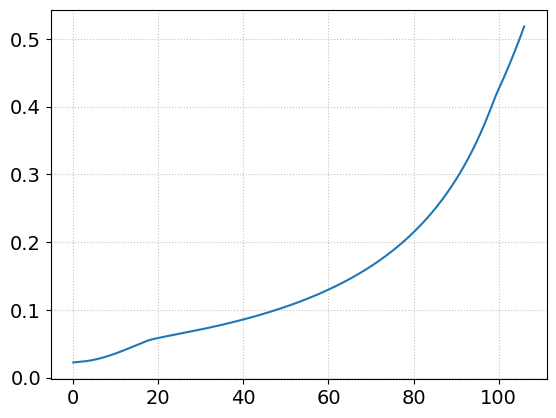

In [173]:
pressure = Dome_C.pressure

gram_to_ppm = 1e18*R*T / (6.022140857e23*pressure*s_open[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)
gram_to_ppm[teller_co:] = 0

#U = (gram_to_ppm * (delta_pa @ delta_ap @ s_open)/(delta_pa @ delta_ap @ s))[:Q]
U = 1e18*R*T / (6.022140857e23*pressure*s[:Q]/rho[:Q]*np.exp(M_air*g*z[:Q]/(R*T))*1e-6)
plt.plot(z[:Q], U)

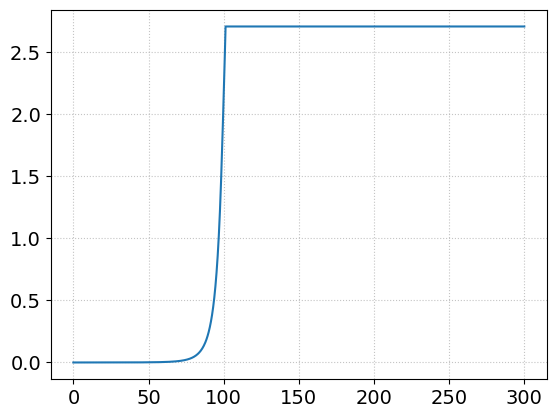

In [174]:
ppm_to_gram_cl = (6.022140857e23 * pressure * s_closed / rho * bubble_pres * 1e-6)/(1e18*R*T)
plt.plot(z, ppm_to_gram_cl)

## Trapping Rate

$$Tr(a,t'') = tr(a-At'')/\sum_{t'''}^{a/A} tr(At''') dt'''$$

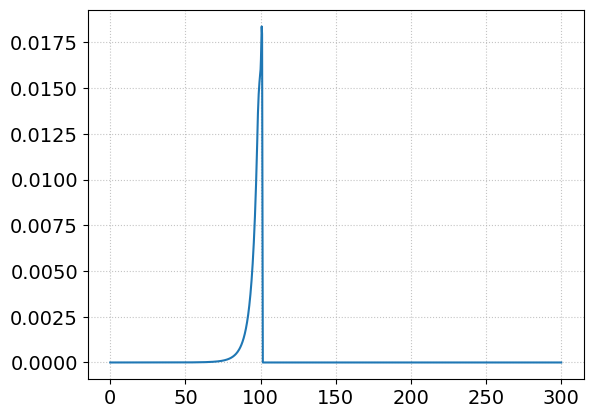

In [175]:
trapping_t = rho*smooth_diff(s_closed*bubble_pres/rho)/dz # Acc*rho_ice/v_ice = Acc*rho_ice/(Acc*rho_ice/rho) = rho
plt.plot(z, trapping_t)

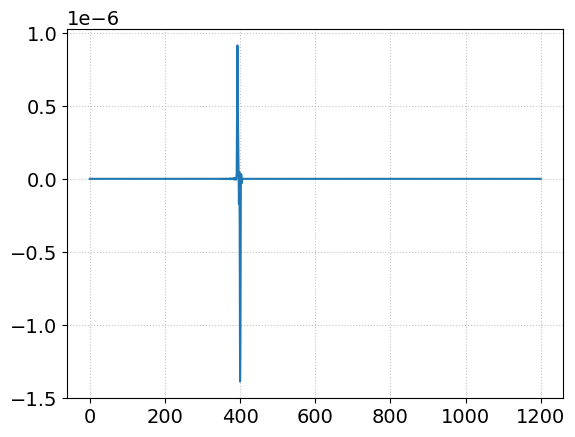

In [176]:
plt.plot(trapping_t-Dome_C.trapping)

In [178]:
dt2 = dt1
t2 = t1-t1[0]
#i = np.arange(len(t2))
#Trap = trapping_t[(i[:,None]-i[None,:]).clip(min=0)]/np.cumsum(trapping_t*dt2)[:,None] * (i[:,None]>=i[None,:])
z_hist = np.interp(age[:,None] - t2[None,:], age_grid, z_grid, left=-10)
i_ht = np.sum(t2[:,None]<=age[None,:], axis=0)-1
Trap = np.interp(z_hist, z, trapping_t)/np.cumsum(np.interp(t2, age, trapping_t)*dt2)[i_ht,None]
#axis0 - accumulation depth (a)
#axis1 - trapping time (t2)
Trap.shape

(1201, 1001)

In [179]:
dt2 = dt1
t2 = t1-t1[0]
z_hist = np.interp(age[:,None] - t2[None,:], age, z, left=-10)

M_trapping = np.interp(z_hist, z, trapping_t, left=0)
M_Trap = M_trapping/np.sum(M_trapping*dt2,axis=1,keepdims=True)

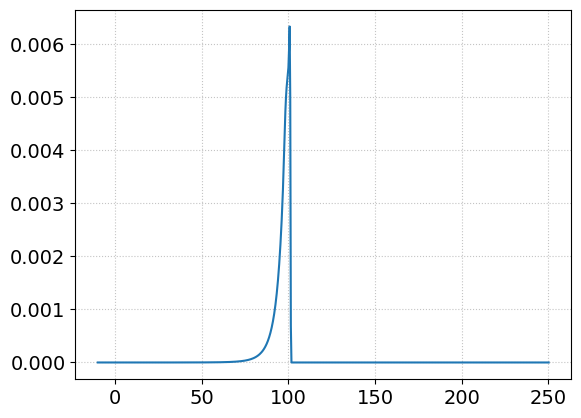

In [180]:
i=-200
plt.plot(z_hist[i],M_Trap[i])

## Interpolation Matrices

$\hat{H}$ - accumulation depth interpolation operator (interpolates production depths to h'(h,t))

$$H_i(h') = (\frac{h'-h_{i-1}}{h_i-h_{i-1}}).\text{clip}(0,1) - (\frac{h'-h_{i}}{h_{i+1}-h_{i}}).\text{clip}(0,1)$$

$h'(h,t)$ - depth at time $t$ of ice parcel w/ present accumulation depth $h$

$h_i$ - propagation depths (for $i$<0 or $i$>max, replace the terms with $h'\geq h_0$ and $h'>h_{\text{max}}$, respectively)

Is the transpose the same as the inverse?

iff the matrix is orthonormal

In [181]:
def interp_mat(out, grid_in): # interpolates from grid_in to out
    # input arrays must have broadcastable shape
    # grid's primary index should be along axis -1
    slope = ((out[...,:-1 if out.shape[-1]>1 else None]-grid_in[...,:-1])/np.diff(grid_in,axis=-1)).clip(0,1) # slope from 0 to 1 as x passes from lower to upper bound
    return np.concatenate(
        [1*(out[...,:1]>=grid_in[...,:1])-slope[...,:1],
         -np.diff(slope, axis=-1),
         slope[...,-1:]-1*(out[...,-1:]>grid_in[...,-1:])],
        axis=-1)

In [182]:
#Interpolate from production depths (p) to accumulation depths (a)
#delta_pa = interp_mat(h[:,None],p[None,:])
delta_pa = interp_mat(z[:,None],np.array([0,*p_z])[None,:])[:,1:]
#axis0 - accumulation depth (a)
#axis1 - production depth (p)
delta_pa.shape

(1201, 836)

In [183]:
#Interpolate from production depths (p) to accumulation depths (a)
#delta_ap = interp_mat(p[:,None],h[None,:])
delta_ap = interp_mat(p_z[:,None],z[None,:])
#axis0 - production depth (p)
#axis1 - accumulation depth (a)
delta_ap.shape

(836, 1201)

In [184]:
#Interpolate from production depths (p) to past accumulation depths (a'=a+At)
#h_hist = np.interp(age[:,None] + t1[None,:], age_grid, h_grid) - 10*(age[:,None]+t1[None,:] < 0)
#delta_pat1 = np.swapaxes(interp_mat(h_hist[:,:,None], p[None,None,:]), 1,2)
#axis0 - accumulation depth (a)
#axis1 - production depth (p)
#axis2 - production time (t1)
#delta_pat1.shape

In [185]:
#Interpolate from production depths (p) to past accumulation depths (a'=a+At)
#delta_pahist = np.moveaxis(interp_mat(h_hist[:,:,None],p[None,None,:]), 0, -1)
#delta_pahist = np.einsum('ap, ta -> apt', delta_pa, delta_aahist)
#axis0 - accumulation depth (a)
#axis1 - production depth (p)
#axis2 - production time (t1)
#delta_pahist.shape

## Sample Average Matrix

$\hat{S}$ - sample operator (averages over each sample depth range in accumulation depth)

$$S(s,h) = \frac{(s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}{\sum_h (s^+ - h^-).\text{clip}(0,\Delta h) - (s^- - h^-).\text{clip}(0,\Delta h)}$$

$s$ - sample depth bins (+ upper bound, - lower bound)

$h$ - accumulation depth bins (- lower bound, $\Delta$ width)

In [186]:
S_mat = (h_samp_bins[1,:,None]-h[None,:]).clip(0,dh[None,:]) - (h_samp_bins[0,:,None]-h[None,:]).clip(0,dh[None,:])
S_mat /= np.sum(S_mat, axis=-1, keepdims=True)
#axis0 - Sample Depth
#axis1 - Accumulation Depth
S_mat.shape

(16, 1201)

# Accumulation Tensors

## Grains

Assuming $p=At'$, corresponding to our production time grid:

$$\vec{c}^{\text{grains}}_{a,t} = \sum_{t'}(\vec{R}\cdot\hat{A}^{\text{grains}})_{t'}(\vec{P}\cdot\vec{f})_{a+At'}\vec{\phi}_{t'+t}$$

If we instead let $p$ have a different grid shape than $At'$,

$$\vec{c}^{\text{grains}}_{a,t} = \sum_{t',p} (\vec{R}\cdot\hat{A}^{\text{grains}})_{t'}\hat{\delta}_{p,a+At'}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t'+t}$$

$$\hat{A}^{\text{grains}}_{l,t} = (1-\vec{L})^{-t'} e^{\lambda t'} dt'$$

where $\hat{\delta}_{p,a+At'}$ acts as a linear interpolation from $p$ to $a+At'$

Original calculation steps:
- 14C production at production depths
- Leakage
- Decay
- Advection (step down by 1 timestep)

In [187]:
A_grains = (1-L[:,None])**(-t1[None,:]+dt1) * np.exp(lambd*(t1[None,:]-dt1)) * dt1
#axis0 - leakage rate (L)
#axis1 - production time (t1)
A_grains.shape

(2, 1001)

In [188]:
i = np.arange(len(p))
j = np.arange(len(p))
k = np.arange(len(t1))-len(t1)
delta_ppt1 = i[None,None,:] == j[None,:,None] + k[:,None,None]
#axis0 - production time (k)
#axis1 - present depth (j)
#axis2 - past depth (i)

In [189]:
A_grains_full = np.einsum('ai, tip, lt -> lap', delta_pa, delta_ppt1, A_grains, optimize=True)
#axis0 - leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)

In [190]:
Lrate = -np.log(1-L)[None,:]
grains = np.exp(-(lambd+Lrate)*(p_age[:,None]+p_dt)) * np.cumsum(P[:,None] * np.exp((lambd+Lrate)*p_age[:,None]) * p_dt, axis=0)
grains[~np.isfinite(grains)] = 0
grains[1:] = grains[:-1]
grains[0] = 0

/tmp/ipykernel_1471/1780142108.py:1: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)[None,:]
/tmp/ipykernel_1471/1780142108.py:2: RuntimeWarning: invalid value encountered in multiply
  grains = np.exp(-(lambd+Lrate)*(p_age[:,None]+p_dt)) * np.cumsum(P[:,None] * np.exp((lambd+Lrate)*p_age[:,None]) * p_dt, axis=0)


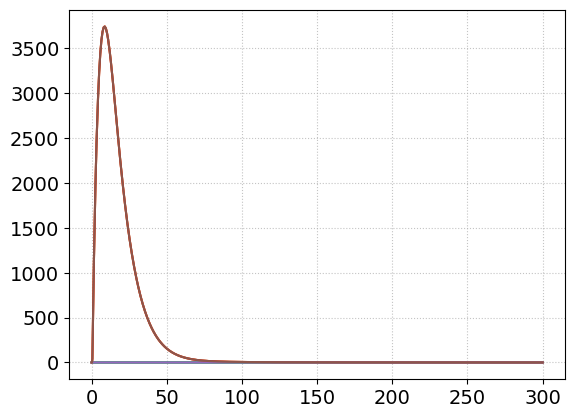

In [191]:
plt.plot(z, (A_grains_full @ P).T)
plt.plot(z, P0_tuning @ C14_grains)
plt.plot(z, delta_pa @ grains)

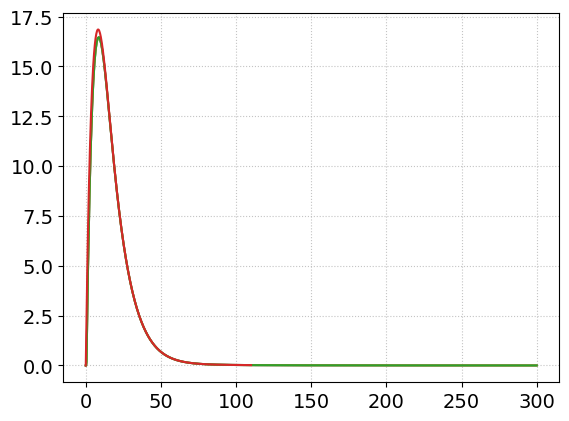

In [192]:
plt.plot(z, (A_grains_full @ P).T @ Res)
plt.plot(Dome_C.z, P0_tuning @ C14_grains @ Res)
plt.plot(z, delta_pa @ grains @ Res)
plt.plot(runMat['z'], runMat['C14_grains'][:,-1,1])

/tmp/ipykernel_1471/4119278782.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(z, (A_grains_full @ P).T/(P0_tuning @ C14_grains)-1)


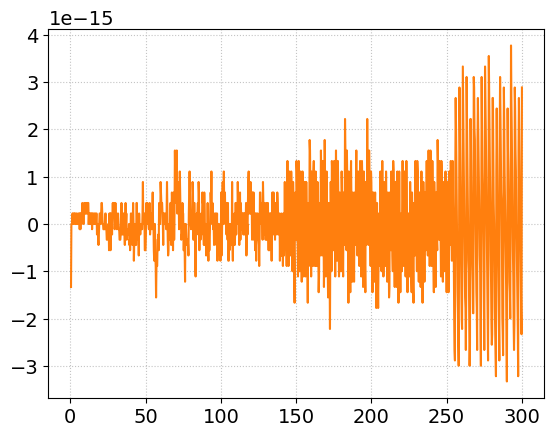

In [193]:
plt.plot(z, (A_grains_full @ P).T/(P0_tuning @ C14_grains)-1)

## Open Porosity

$$\vec{c}^{open}_{a,t} = \sum_{t',p} (\vec{R}\cdot\hat{A}^{open})_{a,p,t'}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t'+t} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t'+t}$$

$$\hat{A}^{\text{open}}_{l,a,p,t'} = [\sum_{t''=0}^{\text{max}(\text{age}_{co},-t')} D^{-t'-t''}_{a,p+At''} U_{p+At''} e^{-\lambda t''}(1-\vec{L})^{t''}(1-(1-\vec{L})^{dt''})]dt'$$

$$\hat{A}^{\text{open}}_{l,a,p,t'} = [\sum_{t''=0}^{\text{max}(\text{age}_{co},-t')} D^{-t'-t''}_{a,a'} U_{a'} \hat{\delta}_{p,a'-At''} e^{-\lambda t''}(1-\vec{L})^{t''}(1-(1-\vec{L})^{dt''})]dt'$$

$$\hat{A}^{\text{open}}_{l,a,p,t'} = [\sum_{t'''=0.5dt'''} D^{t'''}_{a,a'} U_{a'} \hat{\delta}_{p,a'+A(t'+t''')} e^{\lambda (t'+t''')}(1-\vec{L})^{-(t'+t''')}(1-(1-\vec{L})^{dt'''})]dt'$$

$t''$ - leak time; time spent in grain before leaking into open pores, can't be longer than age at close-off depth

$-t'-t''$ - diffusion time; time spent diffusing in open porosity before measurement

$a'=p + At''$ - leak depth; depth at time of leakage (A = accumulation rate)

$\vec{L}$ - annual leakage rates per reservoir (if $L<100\%$, $(1-L)^{t''}= e^{-lt''}$ and $(1-(1-L)^{dt''})=l dt''$)

$$U(a) = U_{g\rightarrow ppm}(a) \frac{s_o(a)}{s(a)}$$

$U(a)$ - open porosity fraction & unit conversion from per gram to ppm at depth $a$

In [194]:
#Interpolate from production depths (p) to past accumulation depths (a'=a+At)
dt2 = dt1
t2 = np.arange(int(age[Q]/dt2))*dt2
h_hist = np.interp(age[None,:Q,None] - t2[:,None,None], age_grid, h_grid, left=-10)
delta_pahist = interp_mat(h_hist, p[None,p<=h[teller_co+1]])
#axis0 - grain time (t2)
#axis1 - past accumulation depth (a')
#axis2 - production depth (p)
delta_pahist.shape

(234, 425, 221)

In [195]:
# apply our unit conversion ahead of time
# to avoid repetitive multiplication
DU = delta_pa[:Q,p<=h[teller_co+1]].T @ ((np.sum(cum_mat_prod(D1,int(dt1/dt_D)), axis=0).T @ D_t)*gram_to_ppm[None,:,None] * dt_D/dt1) * ((delta_ap @ s_open)/(delta_ap @ s).clip(min=1e-20))[None,p<=h[teller_co+1],None]
#axis0 - accumulation depth (a)
#axis1 - diffusion depth (p')
#axis2 - diffusion time (t3=-t1-t2)

100%|████████████████████████████████████████████████████████████████████████████████| 999/999 [00:01<00:00, 843.03it/s]


In [196]:
len(t1)

1001

In [197]:
age[Q]

np.float64(2348.2036869929793)

In [198]:
# sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
A_open = np.zeros((len(L),Q,len(p[p<=h[teller_co+1]]),min(len(t1),int(age[Q]/dt1)+N_D)))
#axis0 - leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)

dt2 = dt1
t2 = np.arange(int(age[Q]/dt2))*dt2
for t2 in tqdm(range(len(t2))): #t2 = time spent in grains before leaking
    A_open[:,:,:-t2 if t2>0 else None,t2:t2+N_D] += DU[None,:,t2:,::-1] * (np.exp(-lambd*t2*dt2) * (1-L)**(t2*dt2))[:,None,None,None]
    #A_open[:,:,:,t2:t2+N_D] += delta_pahist[t2].T @ DU[None,:,:,::-1] * (np.exp(-lambd*t2*dt2) * (1-L)**(t2*dt2))[:,None,None,None]
A_open *= (1-(1-L)**dt2)[:,None,None,None] * dt1

#t1_cut = t1[-int(age[Q]/dt1):]
#dt3 = dt1
#for t3 in tqdm(range(N_D)):
    #A_open[:,:,:,N_D-t3-1:-t3-1] += np.moveaxis(DU[:,:,t3] @ delta_pahist[N_D-t3-1:-t3-1], 0,-1)[None,:,:,:] * (np.exp(lambd*(t1_cut[None,:]+t3*dt3)) * (1-L[:,None])**(-(t1_cut[None,:]+t3*dt3)))[:,None,None,:]
#A_open *= (1-(1-L)**dt3)[:,None,None,None] * dt1
#A_open = delta_pa.T[:,:Q] @ A_open
#axis0 - leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)
A_open.shape

100%|█████████████████████████████████████████████████████████████████████████████████| 234/234 [00:07<00:00, 29.86it/s]


(2, 425, 221, 334)

In [199]:
C_add = gram_to_ppm[:,None] * (delta_pa[:Q] @ ((grains/dt1 + P[:,None])*(1-(1-L[None,:])**dt1)*Dome_C.dt * ((delta_ap @ s_open)/(delta_ap @ s).clip(min=1e-20))[:,None]))
#C_add = gram_to_ppm[:,None] * (P0_tuning @ C14_leak_open)[:Q] * Dome_C.dt
#C_add[1:] = C_add[:-1]
#C_add[0] = 0
c_open = np.linalg.inv(np.identity(Q)-D1) @ C_add

In [200]:
delta_pa[:Q] @ ((grains/dt1 + P[:,None])*(1-(1-L[None,:])**dt1)*Dome_C.dt * ((delta_ap @ s_open)/(delta_ap @ s).clip(min=1e-20))[:,None])

array([[0.00000000e+00, 0.00000000e+00],
       [5.73821598e-01, 2.53053026e-02],
       [1.05196778e+00, 4.82615280e-02],
       [1.00043044e+00, 5.82126631e-02],
       [9.48893110e-01, 6.81637982e-02],
       [8.97355775e-01, 7.81149333e-02],
       [8.50121209e-01, 8.69621905e-02],
       [8.07147421e-01, 9.47163422e-02],
       [7.64173634e-01, 1.02470494e-01],
       [7.21199847e-01, 1.10224646e-01],
       [6.84645936e-01, 1.16338084e-01],
       [6.48741832e-01, 1.22285453e-01],
       [6.12837728e-01, 1.28232822e-01],
       [5.79113484e-01, 1.33624864e-01],
       [5.49029029e-01, 1.38089659e-01],
       [5.18944574e-01, 1.42554453e-01],
       [4.88860119e-01, 1.47019247e-01],
       [4.63123545e-01, 1.50377208e-01],
       [4.37816081e-01, 1.53625932e-01],
       [4.12508617e-01, 1.56874655e-01],
       [3.89295535e-01, 1.59592410e-01],
       [3.67964038e-01, 1.61833144e-01],
       [3.46632541e-01, 1.64073879e-01],
       [3.26059371e-01, 1.66123570e-01],
       [3.080516

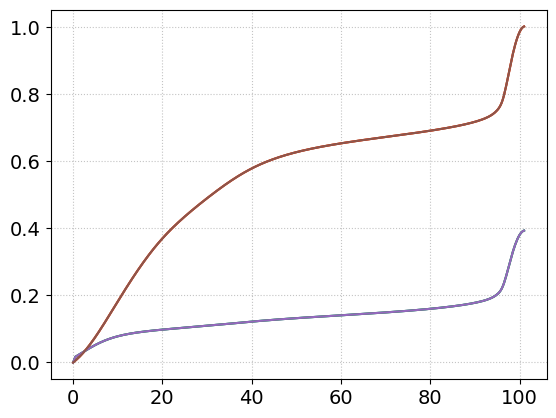

In [201]:
plt.plot(z[:teller_co], (np.sum(A_open[:,:teller_co], axis=-1)@P[p<h[teller_co+1]]).T)
plt.plot(z[:teller_co], P0_tuning @ c_gases[:teller_co,1:].reshape(-1,3,2))
plt.plot(z[:teller_co], c_open[:teller_co])

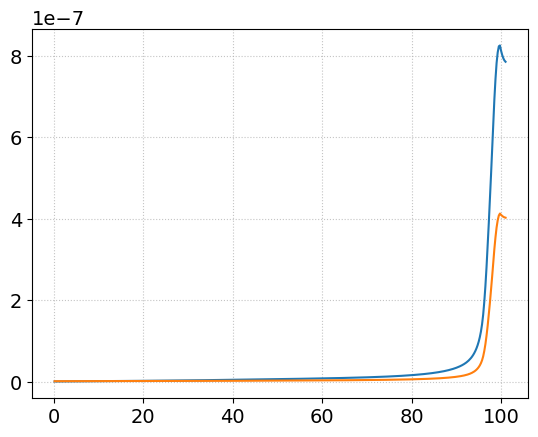

In [203]:
plt.plot(z[1:teller_co], c_open[1:teller_co] / (P0_tuning @ c_gases[1:teller_co,1:].reshape(-1,3,2))-1)

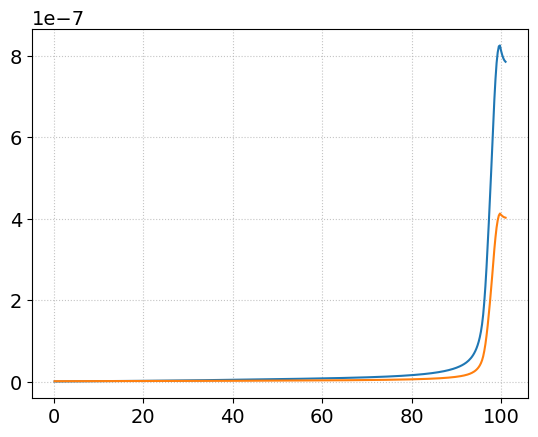

In [204]:
plt.plot(z[1:teller_co], (np.sum(A_open[:,1:teller_co], axis=-1)@P[p<h[teller_co+1]]).T/(P0_tuning @ c_gases[1:teller_co,1:].reshape(-1,3,2))-1)

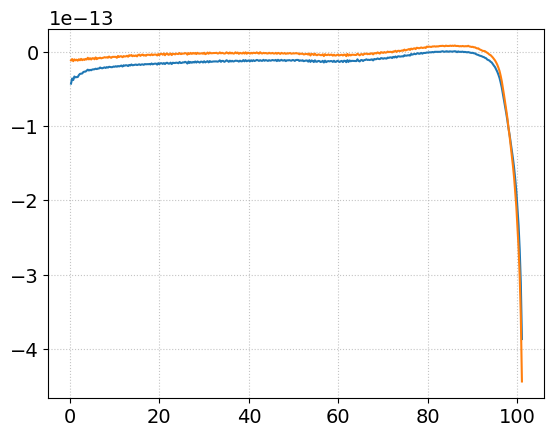

In [206]:
plt.plot(z[1:teller_co], (np.sum(A_open[:,1:teller_co], axis=-1)@P[p<h[teller_co+1]]).T/c_open[1:teller_co]-1)

$$\hat{A}^{atm}_{a,t'} = \hat{D}^{-t'}_{a,0}$$

In [207]:
A_open_atm = np.sum(cum_mat_prod(D1,int(dt1/Dome_C.dt)), axis=0)[:,0] @ D_t[:,:,::-1]
#axis0 - accumulation depth (a)
#axis1 - production time (t1)
A_open_atm.shape

100%|███████████████████████████████████████████████████████████████████████████████| 999/999 [00:00<00:00, 1616.18it/s]


(425, 100)

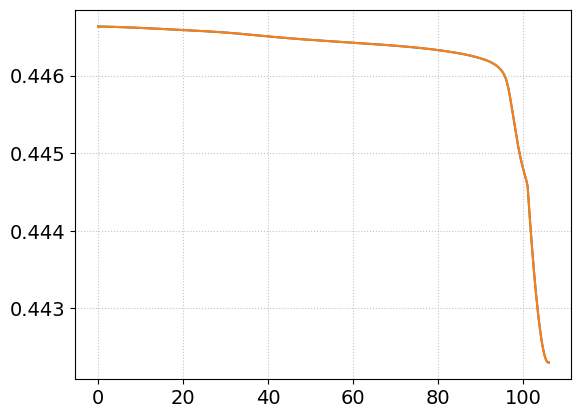

In [208]:
Site = Dome_C
ppm_to_gram = (6.022140857e23 * Site.pressure * Site.s_open / Site.rho * np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)/(1e18*Site.R*Site.T)
ppm_to_gram[Site.teller_co:] = 0

plt.plot(z[:Q], A_open_atm @ gas_history[-N_D:])# * ppm_to_gram[:Q])
plt.plot(z[:Q], c_gases[:Q,0])
#plt.plot(z[:Q], C14_open_atm['C14_CO'][:Q])

/tmp/ipykernel_1471/2471749309.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(z[:Q], A_open_atm @ gas_history[-N_D:] * ppm_to_gram[:Q]/C14_open_atm['C14_CO'][:Q]-1)


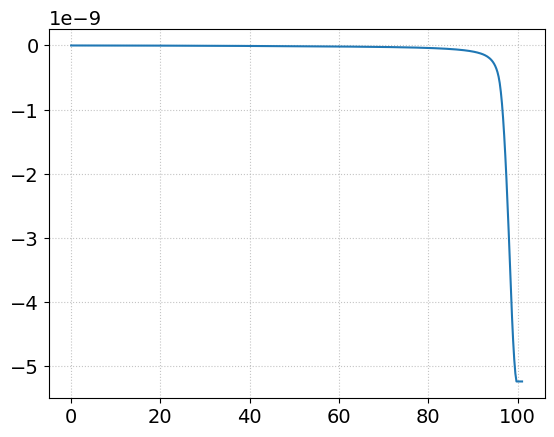

In [209]:
plt.plot(z[:Q], A_open_atm @ gas_history[-N_D:] * ppm_to_gram[:Q]/C14_open_atm['C14_CO'][:Q]-1)

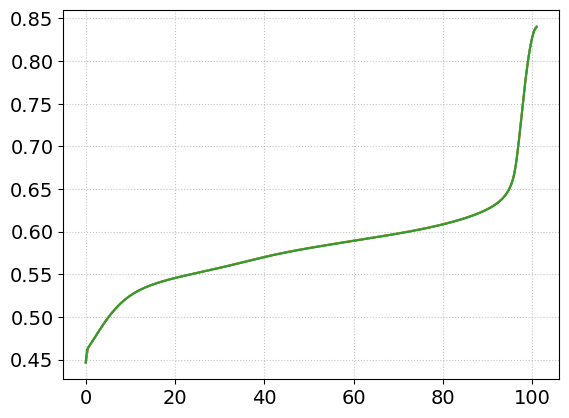

In [213]:
plt.plot(Dome_C.z[:Dome_C.teller_co], P0_tuning @ (c_gases[:Dome_C.teller_co,1:].reshape(-1,3,2)) @ Res + c_gases[:Dome_C.teller_co,0])
plt.plot(z[:teller_co], (np.sum(A_open[:,:teller_co], axis=-1)@P[p<h[teller_co+1]]).T @ Res + A_open_atm[:teller_co] @ gas_history[-N_D:])
plt.plot(runMat['z'], runMat['c_open'][:,-1])

## Closed Porosity

$$\vec{c}^{closed}_{a,t} = \sum_{t',p} (\vec{R}\cdot[\hat{A}^{closed}\hat{\delta}_{p,a+At'} + \hat{A}^{trap}])_{a,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t+t'} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t+t'}$$

$$\hat{A}^{\text{closed}}_{l,p,t'} = e^{\lambda t'}dt'\sum_{t''=0}^{-t'}\frac{s_c(p+At'')}{s(p+At'')}(1-L)^{t''}(1-(1-L)^{dt''})$$

$t''$ - leak time (relative to production)

In [214]:
dt2 = dt1
t2 = t1-t1[0]
#i = np.arange(len(z)) # assuming p=At'
#sc_cast = delta_ap @ np.interp(age[:,None]+t2[None,:], age, s_closed/s) # closed leak fraction at leak time
i = np.arange(len(p))
j = np.arange(len(t2))
#s_cast = np.interp(p_z[(i[:,None]+j[None,:]).clip(max=len(p)-1)], z, s)
sc_cast = ((delta_ap @ s_closed)/(delta_ap @ s).clip(min=1e-20))[(i[:,None]+j[None,:]).clip(max=len(p)-1)]*(i[:,None]+j[None,:]<=len(p)-1)#/s_cast # closed leak fraction at leak time
#axis0 - production depth (p)
#axis1 - grain time (t2)

A_closed = np.cumsum(
    sc_cast[None,:,:] * (1-L[:,None,None])**t2[None,None,:],
    axis=-1
)[:,:,::-1] * (1-(1-L)**dt2)[:,None,None] * np.exp(lambd * t1)[None,None,:] * dt1
#axis0 - Leakage rate (L)
#axis1 - production depth (p)
#axis2 - production time (t1)
A_closed.shape

(2, 836, 1001)

In [215]:
A_closed_full = np.einsum('ai, tip, lpt -> lap', delta_pa, delta_ppt1, A_closed, optimize=True)

In [216]:
leak_closed = (grains/dt1 + P[:,None]) * (1-(1-L[None,:])**dt1) * ((delta_ap @ s_closed)/(delta_ap @ s).clip(min=1e-20))[:,None]
cumuleak_closed = np.exp(-lambd*(p_age[:,None])) * np.cumsum(leak_closed * np.exp(lambd*p_age[:,None]) * dt1, axis=0)
cumuleak_closed[1:] = cumuleak_closed[:-1]
cumuleak_closed[0] = 0

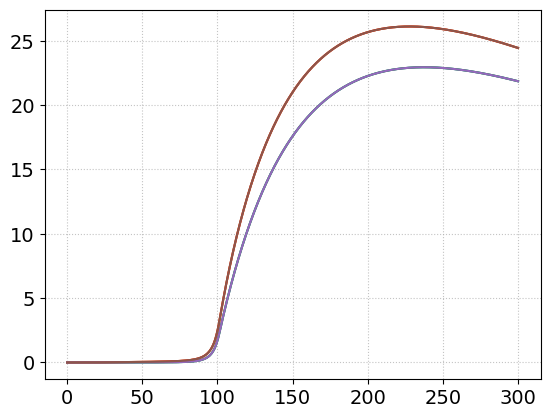

In [217]:
#plt.plot(z, (np.einsum('apt, lpt -> lap', delta_pat1, A_closed, optimize=True) @ P).T)
plt.plot(z, (A_closed_full @ P).T)
plt.plot(z, P0_tuning @ C14_cumuleak_closed)
plt.plot(z, delta_pa @ cumuleak_closed)

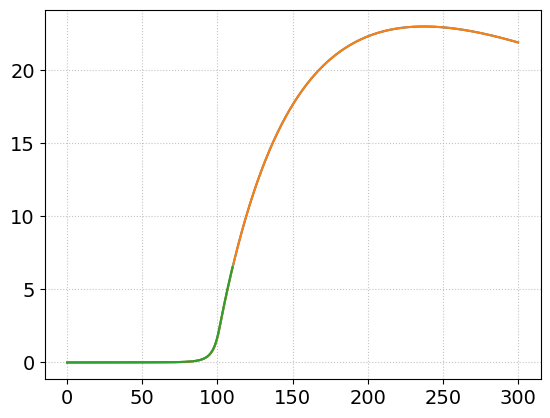

In [222]:
plt.plot(z, (A_closed_full @ P).T @ Res)
plt.plot(Dome_C.z, P0_tuning @ (C14_cumuleak_closed) @ Res)
plt.plot(runMat['z'], runMat['C14_closed'][:,-2,1])

/tmp/ipykernel_1471/1582961502.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(z, (delta_pa @ cumuleak_closed)/(P0_tuning @ C14_cumuleak_closed)-1)


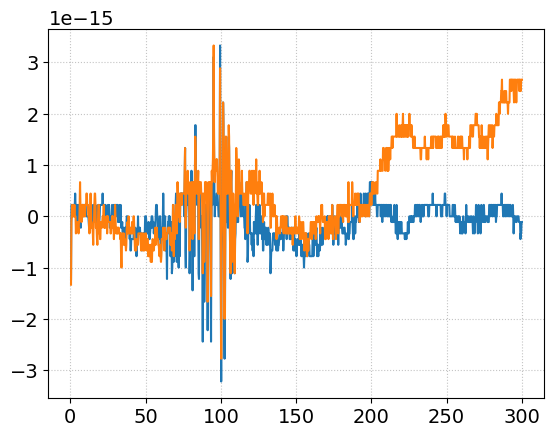

In [218]:
plt.plot(z, (delta_pa @ cumuleak_closed)/(P0_tuning @ C14_cumuleak_closed)-1)

/tmp/ipykernel_1471/168483599.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(z, (A_closed_full @ P).T/(P0_tuning @ C14_cumuleak_closed)-1)


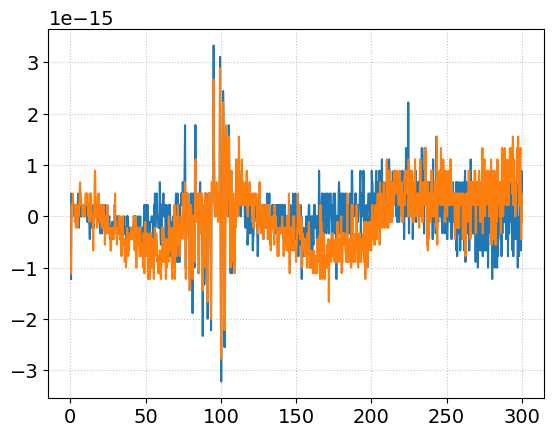

In [219]:
plt.plot(z, (A_closed_full @ P).T/(P0_tuning @ C14_cumuleak_closed)-1)

/tmp/ipykernel_1471/786808638.py:1: RuntimeWarning: invalid value encountered in divide
  plt.plot(z, (A_closed_full @ P).T/(delta_pa @ cumuleak_closed)-1)


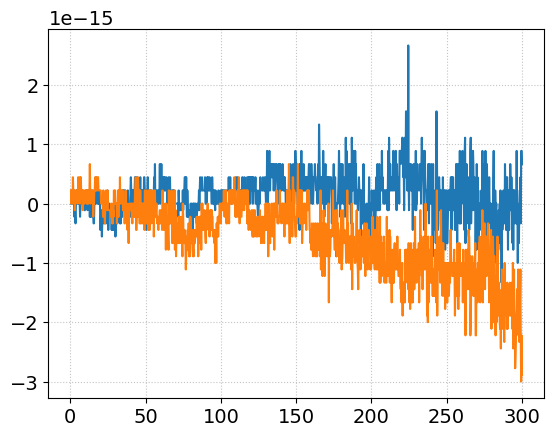

In [220]:
plt.plot(z, (A_closed_full @ P).T/(delta_pa @ cumuleak_closed)-1)

$$\hat{A}^{trap}_{l,a,p,t'} = U_{ppm\rightarrow g}(a)\sum_{t''}^{-t'}e^{-\lambda t''}Tr(a,t'')\hat{\delta}_{a',a-At''}\hat{A}^{open}_{l,a',p,-t'-t''}dt''$$

$$\hat{A}^{atm}_{a,t'} = U_{ppm\rightarrow g}(a)\sum_{t''}e^{-\lambda t''}Tr(a,t'')\hat{\delta}_{a',a-At''}\hat{A}^{atm}_{a',-t'-t''}dt''$$

$t''$ - time in closed grain after getting trapped

Note: I think $U_{ppm\rightarrow g}$ should be applied at trapping depth, but in the firn model it is applied at final depth

In [224]:
N_op = A_open.shape[-1]
A_trap = np.zeros((len(L), len(z), len(p), len(t1)+N_op))
p_lim = len(p[p<=h[teller_co+1]])
dt2 = dt1
t2 = t1-t1[0]
A_open_interp = interp1d(z[:Q], A_open, axis=1, bounds_error=False, fill_value=0, assume_sorted=True)
#A_open_p = np.einsum('ia, lapt -> lipt', delta_ap[:p_lim,:Q], A_open, optimize=True)
z_hist = np.interp(age[None,:] - t2[:,None], age, z, left=-10)

#Trap_p = delta_ap @ Trap

for t2 in tqdm(range(len(t1))):
    A_trap[:,:,:p_lim,t2:t2+N_op] += np.exp(-lambd*t2*dt2) * M_Trap[None,:,None,None,t2] * A_open_interp(z_hist[t2])[:,:,:,::-1] * dt2
    #A_trap[:,t2:t2+p_lim,:p_lim,t2:t2+N_op] += np.exp(-lambd*t2*dt2) * Trap_p[None,t2:t2+p_lim,None,None,t2] * A_open_p[:,:max(len(p)-t2,0),:,len(t1)-t2-1::-1] * dt2
#A_trap = np.einsum('ai, lipt -> lapt', delta_pa, A_trap, optimize=True)
#A_trap = interp1d(p, A_trap, axis=1, bounds_error=False, fill_value=0, assume_sorted=True)(h)
A_trap *= ppm_to_gram_cl[None,:,None,None]
A_trap[...,len(t1)-1] += np.sum(A_trap[...,len(t1):],axis=-1)
A_trap = A_trap[...,:len(t1)]
#axis0 - Leakage rate (L)
#axis1 - accumulation depth (a)
#axis2 - production depth (p)
#axis3 - production time (t1)
A_trap.shape

100%|███████████████████████████████████████████████████████████████████████████████| 1001/1001 [39:14<00:00,  2.35s/it]


(2, 1201, 836, 1001)

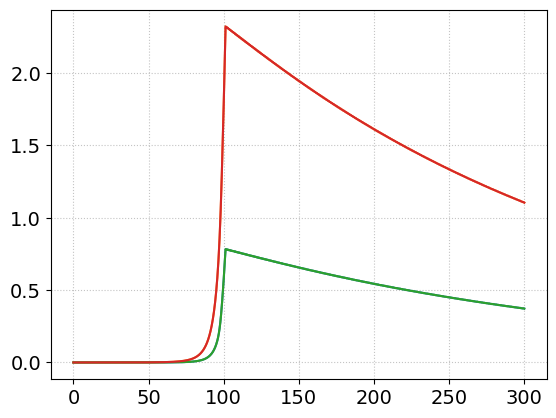

In [225]:
plt.plot(z, (np.sum(A_trap, axis=-1)@P).T)
plt.plot(z, P0_tuning @ C14_closed_gas['C14_CO'])

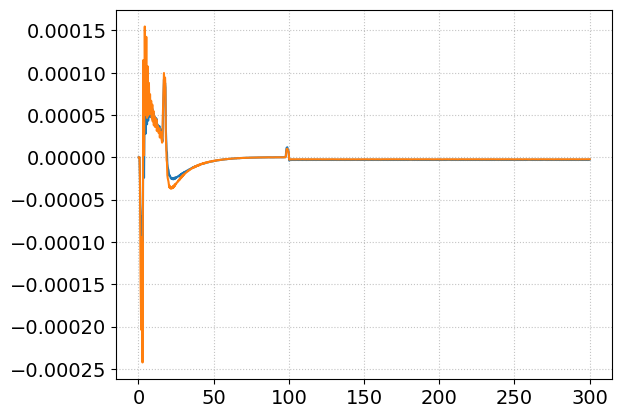

In [226]:
plt.plot(z[1:], (np.sum(A_trap, axis=-1)@P).T[1:] /(P0_tuning @ C14_closed_gas['C14_CO'])[1:]-1)

In [227]:
A_trap_atm = np.zeros((len(z), len(t1)+N_D))
p_lim = len(p[p<=h[teller_co+1]])
dt2 = dt1
t2 = t1-t1[0]
A_atm_interp = interp1d(z[:Q], A_open_atm, axis=0, bounds_error=False, fill_value=0, assume_sorted=True)
A_atm_p = delta_ap[:p_lim,:Q] @ A_open_atm
z_hist = np.interp(age[None,:] - t2[:,None], age, z, left=-10)

Trap_p = delta_ap @ Trap

for t2 in tqdm(range(len(t2))):
    #A_trap_atm[:,t2:t2+N_D] += np.exp(-lambd*t2*dt2) * M_Trap[:,None,t2] * A_atm_interp(z_hist[t2])[:,len(t1)-t2-1::-1] * dt2
    A_trap_atm[:,t2:t2+N_D] += np.exp(-lambd*t2*dt2) * M_Trap[:,None,t2] * A_atm_interp(z_hist[t2])[:,::-1] * dt2
    #A_trap_atm[t2:t2+p_lim,t2:t2+N_D] += np.exp(-lambd*t2*dt2) * Trap_p[t2:t2+p_lim,None,t2] * A_atm_p[:max(len(p)-t2,0),len(t1)-t2-1::-1] * dt2
    #A_trap_atm[:,t2:t2+N_D] += np.exp(-lambd*t2*dt2) * Trap[:,None,t2] * (delta_pa[:,t2:t2+p_lim] @ A_atm_p[:max(len(p)-t2,0),len(t1)-t2-1::-1]) * dt2
#A_trap_atm = delta_pa @ A_trap_atm
#A_trap_atm = interp1d(p, A_trap_atm, axis=0, bounds_error=False, fill_value=0, assume_sorted=True)(h)
A_trap_atm *= ppm_to_gram_cl[:,None]
A_trap_atm[:,len(t1)-1] += np.sum(A_trap_atm[:,len(t1):],axis=-1)
A_trap_atm = A_trap_atm[:,:len(t1)]
#axis0 - accumulation depth (a)
#axis1 - production time (t1)
A_trap_atm.shape

100%|█████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:00<00:00, 1311.68it/s]


(1201, 1001)

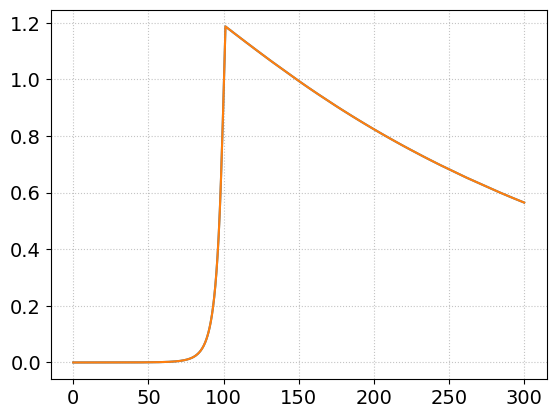

In [230]:
plt.plot(z, A_trap_atm @ gas_history)
plt.plot(z, C14_closed_atm['C14_CO'])

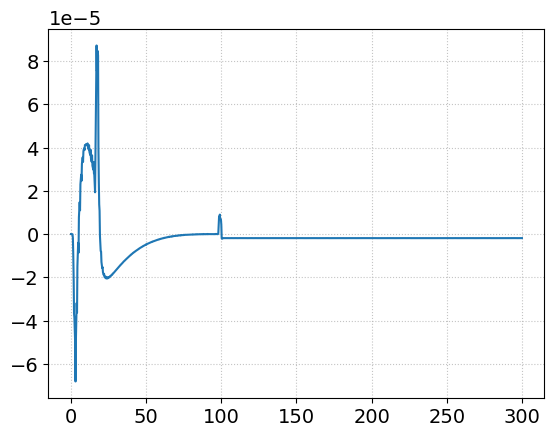

In [229]:
plt.plot(z, A_trap_atm @ gas_history/C14_closed_atm['C14_CO']-1)

## Total Concentration

$$\hat{A}_{l,s,p,t'} = \hat{S}_{s,a}\cdot[\hat{A}^{grains}\hat{\delta}_{p,a+At'}+\hat{A}^{closed}\hat{\delta}_{p,a+At'}+\hat{A}^{trap}]_{l,a,p,t'}$$

$$\hat{A}^{atm}_{s,t'} = \hat{S}\cdot \hat{A}^{atm}$$

$$\vec{c}^{pred}_s = \sum_{t',p} (\vec{R}\cdot\hat{A})_{s,p,t'}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t'} + \sum_{t'}\hat{A}^{atm}_{s,t'}\vec{c}_{t'}^{atm}$$

$$\Sigma^{pred}_{ss'} = (\vec{R} \hat{A}\vec{\phi})_{s,p}(\vec{f}\Sigma^{prod}\vec{f}^T)_{p,p'}(\vec{R} \hat{A}\vec{\phi})^T_{p',s'} + (\hat{A}^{atm})_{s,t}\Sigma^{atm}_{t,t'}(\hat{A}^{atm})^T_{t',s'}$$

In [ ]:
A_profile = (A_grains[:,None,None,:] + A_closed[:,:,None,:])*delta_pahist[None,:,:,:] + A_trap
A_total = np.einsum('sa, lapt->lspt', S_mat, A_profile)
A_total.shape

In [ ]:
A_atm = S_mat @ A_trap_atm
A_atm.shape